# **Insights from City Supply and Demand Data**

*This data project has been used as a take-home assignment in the recruitment process for the data science positions at Uber.*

## Assignment

Using the provided dataset, answer the following questions:

1. Which date had the most completed trips during the two week period?
2. What was the highest number of completed trips within a 24 hour period?
3. Which hour of the day had the most requests during the two week period?
4. What percentages of all zeroes during the two week period occurred on weekend (Friday at 5 pm to Sunday at 3 am)?
   **Tip**: The local time value is the start of the hour (e.g. `15` is the hour from 3:00pm - 4:00pm)
5. What is the weighted average ratio of completed trips per driver during the two week period?
   **Tip**: "Weighted average" means your answer should account for the total trip volume in each hour to determine the most accurate number in the whole period.
6. In drafting a driver schedule in terms of 8 hours shifts, when are the busiest 8 consecutive hours over the two week period in terms of unique requests? A new shift starts every 8 hours. Assume that a driver will work the same shift each day.
7. **True or False**: Driver supply always increases when demand increases during the two week period.
   **Tip**: Visualize the data to confirm your answer if needed.
8. In which 72 hour period is the ratio of Zeroes to Eyeballs the highest?
9. If you could add 5 drivers to any single hour of every day during the two week period, which hour should you add them to?
   **Hint**: Consider both rider eyeballs and driver supply when choosing
10. **True or False**: There is exactly two weeks of data in this analysis.
11. Looking at the data from all two weeks, which time might make the most sense to consider a true "end day" instead of midnight? (i.e when are supply and demand at both their natural minimums)
   **Tip**: Visualize the data to confirm your answer if needed.

## Data Description

To answer the questions, use the dataset from the file `dataset_1.csv`. For example, consider row 11 from this dataset:

| Date       | Time (Local) | Eyeballs | Zeroes | Completed Trips | Requests | Unique Drivers |
|------------|--------------|----------|--------|-----------------|----------|----------------|
| 2012-09-10 | 16           | 11       | 2      | 3               | 4        | 6              |

This means that during the hour beginning at 4pm (hour **16**), on September 10th, 2012, **11** people opened the Uber app (Eyeballs). **2** of them did not see any car (Zeroes) and **4** of them requested a car (Requests). Of the 4 requests, only **3** complete trips actually resulted (Completed Trips). During this time, there were a total of **6** drivers who logged in (Unique Drivers).

## Practicalities

Please work on the questions in the displayed order. Make sure that the solution reflects your entire thought process - it is more important how the code is structured rather than the final answers. You are expected to spend no more than 2-3 hours solving this project.


## Data Exploration

Read the dataset and observe the columns as in the overview.

In [1]:
import pandas as pd
import numpy as np
# read dataset
df = pd.read_csv("datasets/dataset_1.csv")
df.head(10)

,Date,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers
0,10-Sep-12,7,5,0,2,2,9
1,NaN,8,6,0,2,2,14
2,NaN,9,8,3,0,0,14
3,NaN,10,9,2,0,1,14
4,NaN,11,11,1,4,4,11
5,NaN,12,12,0,2,2,11
6,NaN,13,9,1,0,0,9
7,NaN,14,12,1,0,0,9
8,NaN,15,11,2,1,2,7
9,NaN,16,11,2,3,4,6


In [2]:
df.columns

Index(['Date', 'Time (Local)', 'Eyeballs ', 'Zeroes ', 'Completed Trips ',
       'Requests ', 'Unique Drivers'],
      dtype='object')

In [3]:
df.isna().sum()

Date                321
Time (Local)          0
Eyeballs              0
Zeroes                0
Completed Trips       0
Requests              0
Unique Drivers        0
dtype: int64

## Question 1

**Which date had the most completed trips during the two week period?**

In [4]:
# forward fill empty Dates
df = df.ffill()
df

,Date,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers
0,10-Sep-12,7,5,0,2,2,9
1,10-Sep-12,8,6,0,2,2,14
2,10-Sep-12,9,8,3,0,0,14
3,10-Sep-12,10,9,2,0,1,14
4,10-Sep-12,11,11,1,4,4,11
...,...,...,...,...,...,...,...
331,24-Sep-12,2,3,3,0,2,0
332,24-Sep-12,3,3,3,0,1,0
333,24-Sep-12,4,1,1,0,0,0
334,24-Sep-12,5,4,2,1,1,3


In [5]:
# aggregate on Date since the question asks the completed trips by Date
df_agg_date = df.groupby('Date').sum().reset_index()
df_agg_date.nlargest(1, 'Completed Trips ')

,Date,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers
12,22-Sep-12,276,960,219,248,344,292


In [6]:
df_agg_date.nlargest(1, 'Completed Trips ')['Date']

12    22-Sep-12
Name: Date, dtype: object

## Question 2

**What was the highest number of completed trips within a 24 hour period?**

In [12]:
df.columns = df.columns.str.strip()


def create_timestamp(date, time):
    return pd.to_datetime(f"{date} {time}:00")

df['Timestamp'] = df.apply(lambda row: create_timestamp(row['Date'], row['Time (Local)']), axis=1)


numeric_cols = ['Eyeballs', 'Zeroes', 'Completed Trips', 'Requests', 'Unique Drivers']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Rolling sum with 24-hour window
indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=24)
df_agg_twentyfour_hrs = df.set_index("Timestamp")[numeric_cols].rolling(window=indexer, min_periods=1).sum()

# Find the row with the highest 'Completed Trips'
df_agg_twentyfour_hrs.nlargest(1, 'Completed Trips')


,Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers
Timestamp,,,,,
2012-09-21 17:00:00,1015.0,207.0,278.0,367.0,349.0


In [8]:
time_format = "%Y/%m/%d %H:%M"
df_agg_twentyfour_hrs['Time Interval']  = df_agg_twentyfour_hrs.index.strftime(time_format) +  "-" + (df_agg_twentyfour_hrs.index + pd.Timedelta('24 hours')).strftime(time_format)
df_agg_twentyfour_hrs

,Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers,Time Interval
Timestamp,,,,,,
2012-09-10 07:00:00,212.0,38.0,29.0,39.0,150.0,2012/09/10 07:00-2012/09/11 07:00
2012-09-10 08:00:00,217.0,38.0,29.0,39.0,146.0,2012/09/10 08:00-2012/09/11 08:00
2012-09-10 09:00:00,222.0,40.0,27.0,37.0,138.0,2012/09/10 09:00-2012/09/11 09:00
2012-09-10 10:00:00,229.0,39.0,27.0,37.0,130.0,2012/09/10 10:00-2012/09/11 10:00
2012-09-10 11:00:00,232.0,38.0,28.0,37.0,124.0,2012/09/10 11:00-2012/09/11 11:00
...,...,...,...,...,...,...
2012-09-24 02:00:00,20.0,10.0,3.0,6.0,10.0,2012/09/24 02:00-2012/09/25 02:00
2012-09-24 03:00:00,17.0,7.0,3.0,4.0,10.0,2012/09/24 03:00-2012/09/25 03:00
2012-09-24 04:00:00,14.0,4.0,3.0,3.0,10.0,2012/09/24 04:00-2012/09/25 04:00


In [11]:
completed_trips = df_agg_twentyfour_hrs.nlargest(1, 'Completed Trips')['Completed Trips'].values[0]
time_interval = df_agg_twentyfour_hrs.nlargest(1, 'Completed Trips')['Time Interval'].values[0]
print("Number of completed trips:", completed_trips)
print("Time Interval:", time_interval)

Number of completed trips: 278.0
Time Interval: 2012/09/21 17:00-2012/09/22 17:00


## Question 3

**Which hour of the day had the most requests during the two week period?**

In [19]:
df_agg_time = df.groupby('Time (Local)')[['Eyeballs', 'Zeroes', 'Completed Trips', 'Requests', 'Unique Drivers']].sum().reset_index()
df_agg_time.nlargest(1, 'Requests')

,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers
23,23,488,193,126,184,119


In [20]:
df_agg_time.nlargest(1, 'Requests')['Time (Local)']

23    23
Name: Time (Local), dtype: int64

## Question 4

**What percentages of all zeroes during the two week period occurred on weekend (Friday at 5 pm to Sunday at 3 am)?**

In [21]:
total_zeroes = df['Zeroes'].sum()
total_zeroes

1429

In [23]:
df['Day'] = pd.to_datetime(df['Date']).dt.dayofweek
weekend_zeroes = df[((df['Day'] == 4) & (df['Time (Local)'] >= 17)) 
                          | (df['Day'] == 5) |
                          ((df['Day'] == 6) & (df['Time (Local)'] < 3))]['Zeroes'].sum()
weekend_zeroes

C:\Users\ikiga\AppData\Local\Temp\ipykernel_14152\4244612731.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Day'] = pd.to_datetime(df['Date']).dt.dayofweek


641

In [24]:
weekend_zeroes_pct = weekend_zeroes / total_zeroes * 100
print(weekend_zeroes_pct,'%')

44.856543037088876 %


## Question 5 

**What is the weighted average ratio of completed trips per driver during the two week period?**

**Tip**: "Weighted average" means your answer should account for the total trip volume in each hour to determine the most accurate number in whole period.

In [26]:
df['completed_trip_ratio_per_driver'] = df['Completed Trips'] / df['Unique Drivers']
df

,Date,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers,Timestamp,Day,completed_trip_ratio_per_driver
0,10-Sep-12,7,5,0,2,2,9,2012-09-10 07:00:00,0,0.222222
1,10-Sep-12,8,6,0,2,2,14,2012-09-10 08:00:00,0,0.142857
2,10-Sep-12,9,8,3,0,0,14,2012-09-10 09:00:00,0,0.000000
3,10-Sep-12,10,9,2,0,1,14,2012-09-10 10:00:00,0,0.000000
4,10-Sep-12,11,11,1,4,4,11,2012-09-10 11:00:00,0,0.363636
...,...,...,...,...,...,...,...,...,...,...
331,24-Sep-12,2,3,3,0,2,0,2012-09-24 02:00:00,0,NaN
332,24-Sep-12,3,3,3,0,1,0,2012-09-24 03:00:00,0,NaN
333,24-Sep-12,4,1,1,0,0,0,2012-09-24 04:00:00,0,NaN
334,24-Sep-12,5,4,2,1,1,3,2012-09-24 05:00:00,0,0.333333


In [28]:
# drop rows with nan 
dataset_without_zero_unique_driver = df[df['Unique Drivers'] > 0]
# calculate weighted average by giving weight as day's completed trip ratio all completed trips
weighted_average_ratio = np.average(dataset_without_zero_unique_driver['completed_trip_ratio_per_driver'], weights=dataset_without_zero_unique_driver['Completed Trips'])
weighted_average_ratio

0.8282775715092395

In [29]:
# check it is not same with normal average
np.average(dataset_without_zero_unique_driver['completed_trip_ratio_per_driver'])

0.4743397876937869

## Question 6

**In drafting a driver schedule in terms of 8 hours shifts, when are the busiest 8 consecutive hours over the two week period in terms of unique requests? A new shift starts in every 8 hours. Assume that a driver will work same shift each day.**

In [31]:
df_agg_eight_hrs = df.set_index("Timestamp").resample('8h').sum()
time_format = "%Y/%m/%d %H:%M"
df_agg_eight_hrs['Time Interval']  = df_agg_eight_hrs.index.strftime(time_format) +  "-" + (df_agg_eight_hrs.index + pd.Timedelta('8 hours')).strftime(time_format)
df_agg_eight_hrs

,Date,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers,Day,completed_trip_ratio_per_driver,Time Interval
Timestamp,,,,,,,,,,
2012-09-10 00:00:00,10-Sep-12,7,5,0,2,2,9,0,0.222222,2012/09/10 00:00-2012/09/10 08:00
2012-09-10 08:00:00,10-Sep-1210-Sep-1210-Sep-1210-Sep-1210-Sep-121...,92,78,10,9,11,89,0,0.831169,2012/09/10 08:00-2012/09/10 16:00
2012-09-10 16:00:00,10-Sep-1210-Sep-1210-Sep-1210-Sep-1210-Sep-121...,156,106,16,15,21,40,0,3.047619,2012/09/10 16:00-2012/09/11 00:00
2012-09-11 00:00:00,11-Sep-1211-Sep-1211-Sep-1211-Sep-1211-Sep-121...,28,33,12,5,7,17,8,1.400000,2012/09/11 00:00-2012/09/11 08:00
2012-09-11 08:00:00,11-Sep-1211-Sep-1211-Sep-1211-Sep-1211-Sep-121...,92,108,11,5,6,58,8,0.690079,2012/09/11 08:00-2012/09/11 16:00
2012-09-11 16:00:00,11-Sep-1211-Sep-1211-Sep-1211-Sep-1211-Sep-121...,156,173,41,30,39,57,8,4.145887,2012/09/11 16:00-2012/09/12 00:00
2012-09-12 00:00:00,12-Sep-1212-Sep-1212-Sep-1212-Sep-1212-Sep-121...,28,39,16,6,13,12,16,2.000000,2012/09/12 00:00-2012/09/12 08:00
2012-09-12 08:00:00,12-Sep-1212-Sep-1212-Sep-1212-Sep-1212-Sep-121...,92,213,15,52,60,113,16,3.766558,2012/09/12 08:00-2012/09/12 16:00
2012-09-12 16:00:00,12-Sep-1212-Sep-1212-Sep-1212-Sep-1212-Sep-121...,156,171,24,33,41,76,16,3.704240,2012/09/12 16:00-2012/09/13 00:00


In [32]:
df_agg_eight_hrs.nlargest(1, 'Requests')

,Date,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers,Day,completed_trip_ratio_per_driver,Time Interval
Timestamp,,,,,,,,,,
2012-09-21 16:00:00,21-Sep-1221-Sep-1221-Sep-1221-Sep-1221-Sep-122...,156,515,88,153,192,198,32,6.357265,2012/09/21 16:00-2012/09/22 00:00


In [33]:
df_agg_eight_hrs.nlargest(1, 'Requests')['Time Interval']

Timestamp
2012-09-21 16:00:00    2012/09/21 16:00-2012/09/22 00:00
Freq: 8h, Name: Time Interval, dtype: object

## Question 7

**True or False: Driver supply always increases when demand increases during the two week period.**

**Tip**: Visualize the data to confirm your answer if needed.

In [35]:
# create empty dataframe with only timestamps
difference_df = pd.DataFrame(df['Timestamp'])
# calculate request differences to catch request increases
difference_df['request_diff'] = df['Requests'].shift(-1) - df['Requests']
# do same of supply side
difference_df['supply_diff'] = df['Unique Drivers'].shift(-1) - df['Unique Drivers']
difference_df

,Timestamp,request_diff,supply_diff
0,2012-09-10 07:00:00,0.0,5.0
1,2012-09-10 08:00:00,-2.0,0.0
2,2012-09-10 09:00:00,1.0,0.0
3,2012-09-10 10:00:00,3.0,-3.0
4,2012-09-10 11:00:00,-2.0,0.0
...,...,...,...
331,2012-09-24 02:00:00,-1.0,0.0
332,2012-09-24 03:00:00,-1.0,0.0
333,2012-09-24 04:00:00,1.0,3.0
334,2012-09-24 05:00:00,1.0,4.0


In [36]:
(difference_df[difference_df['request_diff'] > 0]['supply_diff'] > 0).all().item()

False

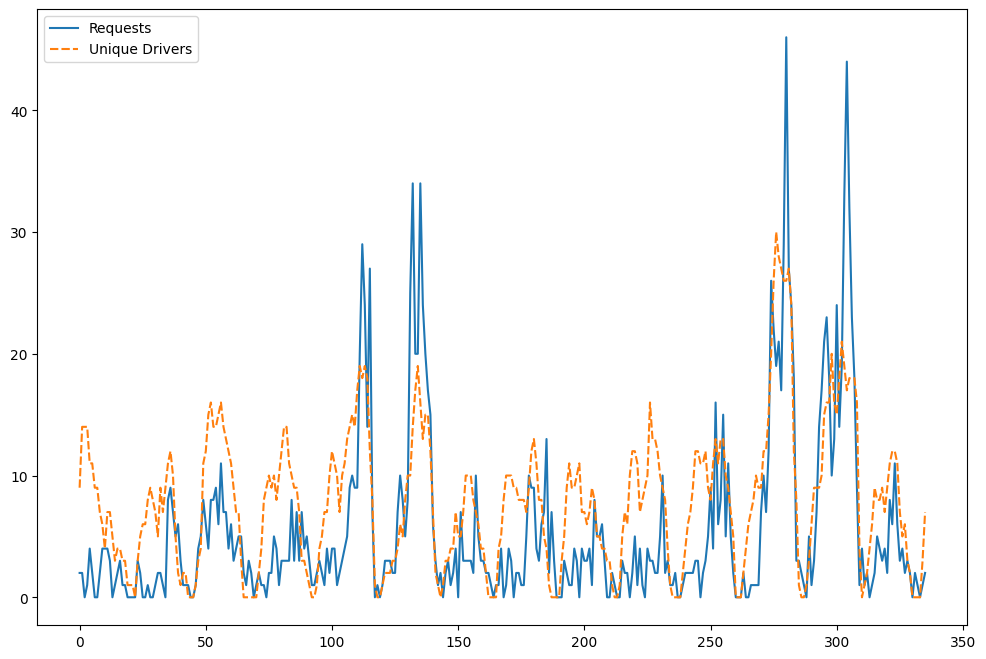

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.lineplot(data=df[['Requests', 'Unique Drivers', 'Timestamp']])
plt.show()

## Question 8

**In which 72 hour period is the ratio of Zeroes to Eyeballs the highest?**

In [43]:
indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=72)

# Set timestamp as index and exclude non-numeric columns before rolling sum
df_numeric = df.set_index("Timestamp").select_dtypes(include="number")

# Perform the rolling sum
df_agg_three_days = df_numeric.rolling(window=indexer, min_periods=1).sum().reset_index()

# Add the 'zeros_to_eyeballs_ratio' column
df_agg_three_days['zeros_to_eyeballs_ratio'] = df_agg_three_days['Zeroes'] / df_agg_three_days['Eyeballs']

# Filter the data for the last three days
df_agg_three_days = df_agg_three_days[
    df_agg_three_days['Timestamp'] <= (df_agg_three_days['Timestamp'].max() - pd.Timedelta(days=3))
]

# Create a formatted time interval column
time_format = "%Y/%m/%d %H:%M"
df_agg_three_days['Time Interval'] = (
    df_agg_three_days['Timestamp'].dt.strftime(time_format) 
    + " - " 
    + (df_agg_three_days['Timestamp'] + pd.Timedelta(days=3)).dt.strftime(time_format)
)

df_agg_three_days

,Timestamp,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers,Day,completed_trip_ratio_per_driver,zeros_to_eyeballs_ratio,Time Interval
0,2012-09-10 07:00:00,828.0,956.0,172.0,159.0,211.0,473.0,93.0,20.807776,0.179916,2012/09/10 07:00 - 2012/09/13 07:00
1,2012-09-10 08:00:00,828.0,961.0,173.0,158.0,210.0,468.0,96.0,20.835553,0.180021,2012/09/10 08:00 - 2012/09/13 08:00
2,2012-09-10 09:00:00,828.0,964.0,174.0,157.0,209.0,462.0,99.0,20.817696,0.180498,2012/09/10 09:00 - 2012/09/13 09:00
3,2012-09-10 10:00:00,828.0,970.0,175.0,157.0,209.0,457.0,102.0,20.817696,0.180412,2012/09/10 10:00 - 2012/09/13 10:00
4,2012-09-10 11:00:00,828.0,976.0,176.0,159.0,210.0,453.0,105.0,21.017696,0.180328,2012/09/10 11:00 - 2012/09/13 11:00
...,...,...,...,...,...,...,...,...,...,...,...
259,2012-09-21 02:00:00,828.0,2209.0,465.0,535.0,724.0,780.0,352.0,39.191989,0.210502,2012/09/21 02:00 - 2012/09/24 02:00
260,2012-09-21 03:00:00,828.0,2207.0,468.0,534.0,724.0,775.0,348.0,38.991989,0.212053,2012/09/21 03:00 - 2012/09/24 03:00
261,2012-09-21 04:00:00,828.0,2207.0,468.0,534.0,725.0,775.0,344.0,38.991989,0.212053,2012/09/21 04:00 - 2012/09/24 04:00
262,2012-09-21 05:00:00,828.0,2208.0,469.0,534.0,725.0,775.0,340.0,38.991989,0.212409,2012/09/21 05:00 - 2012/09/24 05:00


In [44]:
df_agg_three_days.nlargest(1, 'zeros_to_eyeballs_ratio')['zeros_to_eyeballs_ratio']

118    0.292977
Name: zeros_to_eyeballs_ratio, dtype: float64

In [45]:
df_agg_three_days.nlargest(1, 'zeros_to_eyeballs_ratio')['Time Interval']

118    2012/09/15 05:00 - 2012/09/18 05:00
Name: Time Interval, dtype: object

In [48]:
df_agg_three_days.columns

Index(['Timestamp', 'Time (Local)', 'Eyeballs', 'Zeroes', 'Completed Trips',
       'Requests', 'Unique Drivers', 'Day', 'completed_trip_ratio_per_driver',
       'zeros_to_eyeballs_ratio', 'Time Interval'],
      dtype='object')

## Question 9 

**If you could add 5 drivers to any single hour of every day during the two week period, which hour should you add them to?**

**Hint**: Consider both rider eyeballs and driver supply when choosing

In [52]:
df_agg_time = df.groupby('Time (Local)')[['Eyeballs', 'Zeroes', 'Completed Trips', 'Requests', 'Unique Drivers', 'Day', 'completed_trip_ratio_per_driver']].sum().reset_index()
df_agg_time['eyeball_to_driver_ratio'] = df_agg_time['Eyeballs'] / df_agg_time['Unique Drivers'] 
df_agg_time.nlargest(1, 'eyeball_to_driver_ratio')

,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers,Day,completed_trip_ratio_per_driver,eyeball_to_driver_ratio
23,23,488,193,126,184,119,42,11.269306,4.10084


In [53]:
df_agg_time.nlargest(1, 'eyeball_to_driver_ratio')['Time (Local)']

23    23
Name: Time (Local), dtype: int64

## Question 10

**True or False: There is exactly two weeks of data in this analysis**

In [54]:
(df['Timestamp'][df.shape[0]-1]-df['Timestamp'][0])

Timedelta('13 days 23:00:00')

Compare it with timedelta 14 days to see if the difference exactly matches as 14 days

In [55]:
pd.Timedelta('14 days') == df['Timestamp'][df.shape[0]-1]-df['Timestamp'][0]

False

the difference is less than 14 days

In [56]:
pd.Timedelta('14 days') > df['Timestamp'][df.shape[0]-1]-df['Timestamp'][0]

True

## Question 11

**Looking at the data from all two weeks, which time might make the most sense to consider a true "end day" instead of midnight? (i.e when are supply and demand at both their natural minimums)**

**Tip**: Visualize the data to confirm your answer if needed.

In [62]:
# find min supply and demand per day
df_min_supply_per_day = df.groupby(['Date'])['Unique Drivers'].min().reset_index().rename(columns={'Unique Drivers':'min_supply_per_day'})
df_min_demand_per_day = df.groupby(['Date'])['Requests'].min().reset_index().rename(columns={'Requests':'min_demand_per_day'})

# merge demand and supply based on date
supply_demand = pd.merge(df_min_supply_per_day, df_min_demand_per_day, on="Date")
supply_demand

,Date,min_supply_per_day,min_demand_per_day
0,10-Sep-12,3,0
1,11-Sep-12,0,0
2,12-Sep-12,0,0
3,13-Sep-12,0,0
4,14-Sep-12,0,1
5,15-Sep-12,0,0
6,16-Sep-12,0,0
7,17-Sep-12,0,0
8,18-Sep-12,0,0
9,19-Sep-12,0,0


Merge found min values with initial dataset on Date

In [63]:
dataset_w_min_supply_demand = pd.merge(df, supply_demand, on="Date")
dataset_w_min_supply_demand

,Date,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers,Timestamp,Day,completed_trip_ratio_per_driver,min_supply_per_day,min_demand_per_day
0,10-Sep-12,7,5,0,2,2,9,2012-09-10 07:00:00,0,0.222222,3,0
1,10-Sep-12,8,6,0,2,2,14,2012-09-10 08:00:00,0,0.142857,3,0
2,10-Sep-12,9,8,3,0,0,14,2012-09-10 09:00:00,0,0.000000,3,0
3,10-Sep-12,10,9,2,0,1,14,2012-09-10 10:00:00,0,0.000000,3,0
4,10-Sep-12,11,11,1,4,4,11,2012-09-10 11:00:00,0,0.363636,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...
331,24-Sep-12,2,3,3,0,2,0,2012-09-24 02:00:00,0,NaN,0,0
332,24-Sep-12,3,3,3,0,1,0,2012-09-24 03:00:00,0,NaN,0,0
333,24-Sep-12,4,1,1,0,0,0,2012-09-24 04:00:00,0,NaN,0,0
334,24-Sep-12,5,4,2,1,1,3,2012-09-24 05:00:00,0,0.333333,0,0


In [64]:
min_point = dataset_w_min_supply_demand[(dataset_w_min_supply_demand.min_supply_per_day == dataset_w_min_supply_demand['Unique Drivers']) & 
                           (dataset_w_min_supply_demand.min_demand_per_day == dataset_w_min_supply_demand['Requests'])]['Time (Local)'].mode()
min_point

0    4
Name: Time (Local), dtype: int64

In [65]:
min_point[0]

4

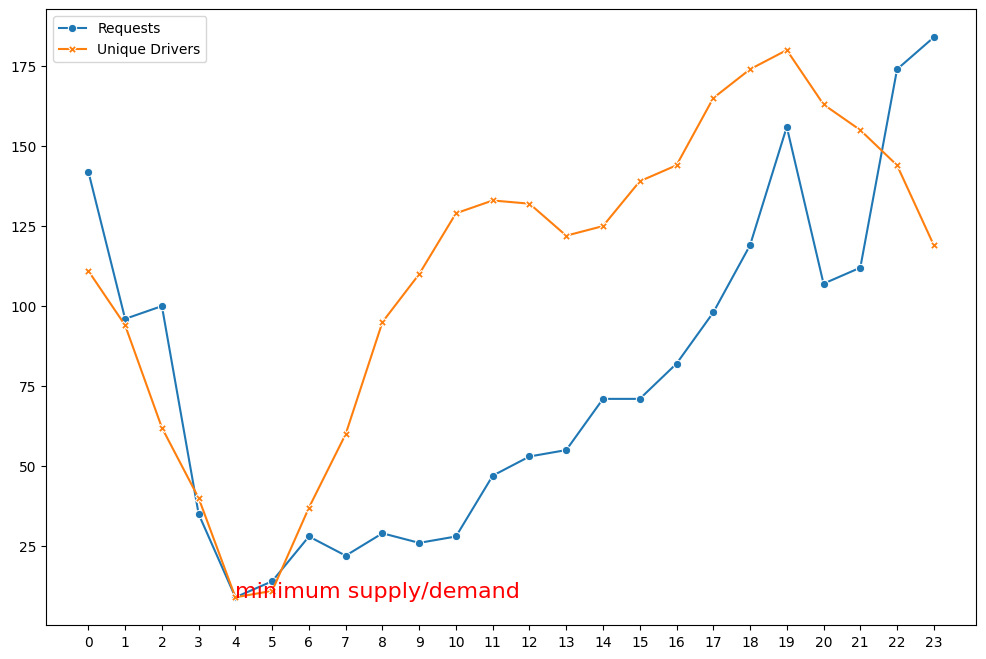

In [69]:
df_agg_time = df.groupby('Time (Local)')[['Requests', 'Unique Drivers']].sum().reset_index()
min_point_value = df_agg_time['Requests'][min_point[0]]
plt.figure(figsize=(12,8))
fig = sns.lineplot(data=df_agg_time[['Requests', 'Unique Drivers']], markers=True, dashes=False)
fig.set_xticks(df_agg_time['Time (Local)'])
plt.annotate('minimum supply/demand', xy=(min_point[0], min_point_value), color='r', fontsize=16)
plt.show()